<a href="https://colab.research.google.com/github/supriya0005/Internship-program/blob/main/AI_taxi_route_optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gymnasium
!pip install flask
!pip install pyngrok
!pip install matplotlib
!pip install numpy
!pip install pandas
!pip install pickle-mixin

  Preparing metadata (setup.py) ... done
  Created wheel for pickle-mixin: filename=pickle_mixin-1.0.2-py3-none-any.whl size=5988 sha256=7f5ecc1e1745c940a1c6bb21ff02546fcfa1b55262313a94db23c0c464ea8588
  Stored in directory: /root/.cache/pip/wheels/69/e2/5c/da8f96a08c63469bc8b10e206cd4c78e8886d8acb8699f84c2
Successfully built pickle-mixin


In [ ]:
# ==========================================
# AI Smart Taxi Route Optimizer
# Cell 2 - Import Libraries
# ==========================================

import gymnasium as gym
import numpy as np
import random
import pickle
import matplotlib.pyplot as plt
import os

# Create Taxi Environment
env = gym.make("Taxi-v4")

# Initialize Q-Table
state_size = env.observation_space.n
action_size = env.action_space.n

q_table = np.zeros((state_size, action_size))

print("=" * 50)
print("AI Smart Taxi Route Optimizer")
print("=" * 50)
print(f"Total States  : {state_size}")
print(f"Total Actions : {action_size}")
print("Q-Table Shape :", q_table.shape)
print("Environment Loaded Successfully!")
print("=" * 50)

# Hyperparameters
learning_rate = 0.1
discount_factor = 0.99
epsilon = 1.0
epsilon_decay = 0.9995
min_epsilon = 0.01

episodes = 5000
max_steps = 100

print("\nTraining Configuration")
print("-------------------------")
print("Episodes        :", episodes)
print("Learning Rate   :", learning_rate)
print("Discount Factor :", discount_factor)
print("Epsilon         :", epsilon)
print("Max Steps       :", max_steps)

reward_history = []

print("\nEverything is Ready!")

AI Smart Taxi Route Optimizer
Total States  : 500
Total Actions : 6
Q-Table Shape : (500, 6)
Environment Loaded Successfully!

Training Configuration
-------------------------
Episodes        : 5000
Learning Rate   : 0.1
Discount Factor : 0.99
Epsilon         : 1.0
Max Steps       : 100

Everything is Ready!


Starting Training...

Episode 500/5000 | Average Reward: -353.87
Episode 1000/5000 | Average Reward: -252.40
Episode 1500/5000 | Average Reward: -141.40
Episode 2000/5000 | Average Reward: -47.71
Episode 2500/5000 | Average Reward: -20.00
Episode 3000/5000 | Average Reward: -9.96
Episode 3500/5000 | Average Reward: -4.59
Episode 4000/5000 | Average Reward: -1.06
Episode 4500/5000 | Average Reward: 1.27
Episode 5000/5000 | Average Reward: 2.88

Training Completed Successfully!
Q-Table saved as q_table.pkl


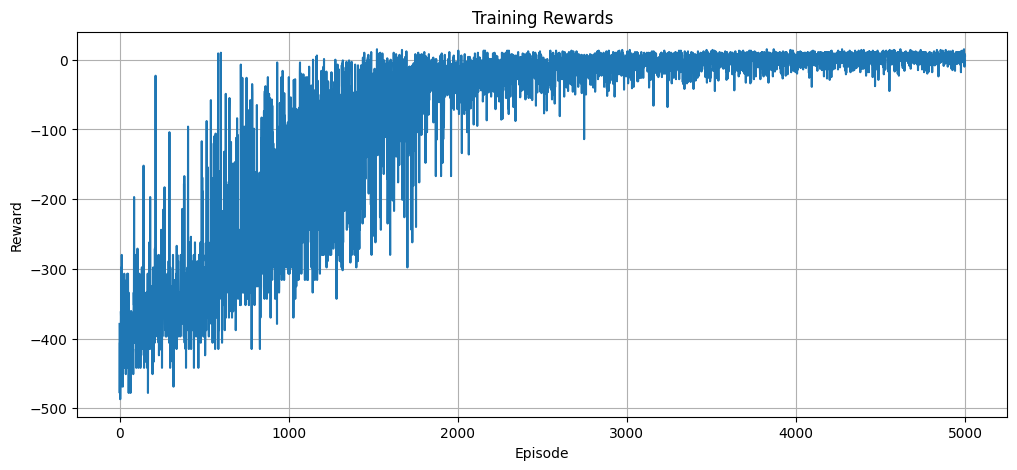


Model is ready for prediction.


In [ ]:
# ==========================================
# Cell 3 - Train the Reinforcement Learning Model
# ==========================================

print("Starting Training...\n")

for episode in range(episodes):

    state, info = env.reset()

    total_reward = 0

    for step in range(max_steps):

        # Epsilon-Greedy Strategy
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        # Take Action
        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        # Q-Learning Update
        old_value = q_table[state, action]
        next_max = np.max(q_table[next_state])

        q_table[state, action] = old_value + learning_rate * (
            reward + discount_factor * next_max - old_value
        )

        state = next_state
        total_reward += reward

        if done:
            break

    reward_history.append(total_reward)

    # Reduce Exploration
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    if (episode + 1) % 500 == 0:
        avg_reward = np.mean(reward_history[-500:])
        print(f"Episode {episode+1}/{episodes} | Average Reward: {avg_reward:.2f}")

print("\nTraining Completed Successfully!")

# Save the trained Q-Table
with open("q_table.pkl", "wb") as file:
    pickle.dump(q_table, file)

print("Q-Table saved as q_table.pkl")

# Plot Training Rewards
plt.figure(figsize=(12,5))
plt.plot(reward_history)
plt.title("Training Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

print("\nModel is ready for prediction.")

In [ ]:
# ==========================================
# Cell 4 - Create Flask Backend
# ==========================================

app_code = '''
from flask import Flask, render_template, jsonify
import gymnasium as gym
import numpy as np
import pickle

app = Flask(__name__)

# Load trained model
with open("q_table.pkl", "rb") as f:
    q_table = pickle.load(f)

env = gym.make("Taxi-v4")

@app.route("/")
def home():
    return render_template("index.html")

@app.route("/predict")
def predict():

    state, info = env.reset()

    total_reward = 0
    steps = []

    done = False

    while not done:

        action = int(np.argmax(q_table[state]))

        next_state, reward, terminated, truncated, info = env.step(action)

        steps.append({
            "state": int(state),
            "action": int(action),
            "reward": int(reward)
        })

        total_reward += reward

        state = next_state

        done = terminated or truncated

    return jsonify({
        "total_reward": int(total_reward),
        "steps": steps,
        "total_steps": len(steps)
    })

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000, debug=False)
'''

# Save app.py
with open("app.py", "w") as f:
    f.write(app_code)

print("✅ app.py created successfully.")

✅ app.py created successfully.


In [ ]:
# ==========================================
# Cell 5 - Create index.html
# ==========================================

import os

os.makedirs("templates", exist_ok=True)
os.makedirs("static", exist_ok=True)

html_code = """
<!DOCTYPE html>
<html lang="en">

<head>

<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">

<title>AI Smart Taxi Route Optimizer</title>

<link rel="stylesheet" href="/static/style.css">

</head>

<body>

<div class="container">

    <h1>🚖 AI Smart Taxi Route Optimizer</h1>

    <p class="subtitle">
        Reinforcement Learning using Q-Learning
    </p>

    <div class="card">

        <h2>Project Dashboard</h2>

        <div class="stats">

            <div class="box">
                <h3>Total Reward</h3>
                <span id="reward">0</span>
            </div>

            <div class="box">
                <h3>Total Steps</h3>
                <span id="steps">0</span>
            </div>

        </div>

        <button onclick="runAI()">
            ▶ Run AI Simulation
        </button>

    </div>

    <div class="card">

        <h2>Simulation Log</h2>

        <div id="log" class="logbox">
            Click the button to start...
        </div>

    </div>

</div>

<script src="/static/script.js"></script>

</body>

</html>
"""

with open("templates/index.html","w") as f:
    f.write(html_code)

print("✅ index.html created successfully.")

✅ index.html created successfully.


In [ ]:
#style.css
# ==========================================
# Cell 6 - Create style.css
# ==========================================

css_code = """

*{
margin:0;
padding:0;
box-sizing:border-box;
font-family:Arial,Helvetica,sans-serif;
}

body{

background:linear-gradient(135deg,#0f172a,#1e293b,#2563eb);
min-height:100vh;
display:flex;
justify-content:center;
align-items:center;
padding:40px;

}

.container{

width:90%;
max-width:1100px;

}

h1{

color:white;
font-size:42px;
text-align:center;
margin-bottom:10px;

}

.subtitle{

text-align:center;
color:#dbeafe;
font-size:18px;
margin-bottom:40px;

}

.card{

background:rgba(255,255,255,0.12);
backdrop-filter:blur(15px);
border-radius:20px;
padding:30px;
margin-bottom:30px;
box-shadow:0 8px 25px rgba(0,0,0,0.35);

}

.card h2{

color:white;
margin-bottom:25px;

}

.stats{

display:flex;
gap:25px;
flex-wrap:wrap;
justify-content:center;

}

.box{

background:white;
border-radius:15px;
padding:25px;
width:220px;
text-align:center;
transition:.3s;

}

.box:hover{

transform:translateY(-8px);

}

.box h3{

color:#2563eb;
margin-bottom:15px;

}

.box span{

font-size:34px;
font-weight:bold;
color:#111827;

}

button{

display:block;
margin:35px auto 0 auto;
padding:15px 35px;
font-size:18px;
border:none;
border-radius:10px;
background:#22c55e;
color:white;
cursor:pointer;
transition:.3s;

}

button:hover{

background:#16a34a;
transform:scale(1.05);

}

.logbox{

margin-top:20px;
background:#111827;
color:#22c55e;
padding:20px;
border-radius:10px;
height:320px;
overflow-y:auto;
font-family:monospace;
font-size:15px;

}

footer{

text-align:center;
color:white;
margin-top:25px;
font-size:15px;

}

@media(max-width:768px){

.stats{

flex-direction:column;
align-items:center;

}

h1{

font-size:30px;

}

button{

width:100%;

}

.box{

width:100%;

}

}

"""

with open("static/style.css","w") as f:
    f.write(css_code)

print("✅ style.css created successfully.")

✅ style.css created successfully.


In [ ]:
#script,js
# ==========================================
# Cell 7 - Create script.js
# ==========================================

js_code = """

async function runAI(){

document.getElementById("log").innerHTML="Running AI Simulation...";

const response=await fetch("/predict");

const data=await response.json();

document.getElementById("reward").innerHTML=data.total_reward;

document.getElementById("steps").innerHTML=data.total_steps;

let output="";

data.steps.forEach((step,index)=>{

output += `
<div style="padding:8px;border-bottom:1px solid #333;">
<b>Step ${index+1}</b><br>
State : ${step.state}<br>
Action : ${step.action}<br>
Reward : ${step.reward}
</div>
`;

});

document.getElementById("log").innerHTML=output;

}

"""

with open("static/script.js","w") as f:
    f.write(js_code)

print("✅ script.js created successfully.")

✅ script.js created successfully.


In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3GLKzHuiRfIvTVNGUHXgnFiAdN5_5wWuH3cjwLtDzb81VfLsE")

In [ ]:
from pyngrok import ngrok
import subprocess
import time

# Kill old tunnels
ngrok.kill()

# Start Flask FIRST
flask_process = subprocess.Popen(["python", "app.py"])

# Wait for Flask to start
time.sleep(8)

# Then create the ngrok tunnel
public_url = ngrok.connect(5000)

print("="*50)
print("Website URL:")
print(public_url.public_url)
print("="*50)
print("Open this URL in your browser.")

Website URL:
https://secluding-commerce-font.ngrok-free.dev
Open this URL in your browser.


In [ ]:
!python app.py





























 * Serving Flask app 'app'
 * Debug mode: off
Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.
